In [269]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [270]:
# Load the digits dataset
digits = datasets.load_digits()

type(digits)

sklearn.utils._bunch.Bunch

In [271]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [272]:
digits.images

array([[[ 0.,  0.,  5., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ..., 15.,  5.,  0.],
        [ 0.,  3., 15., ..., 11.,  8.,  0.],
        ...,
        [ 0.,  4., 11., ..., 12.,  7.,  0.],
        [ 0.,  2., 14., ..., 12.,  0.,  0.],
        [ 0.,  0.,  6., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  5.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  6.,  0.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  3., ..., 14.,  0.,  0.],
        [ 0.,  0.,  8., ..., 16.,  0.,  0.],
        ...,
        [ 0.,  9., 16., ...,  0.,  0.,  0.],
        [ 0.,  3., 13., ..., 11.,  5.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.]],

       ...,

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ...,  2.,  1.,  0.],
        [ 0.,  0., 16., ..., 16.,  5.,  0.

In [273]:
import pandas as pd

# suppose dataset = load_digits() or similar
df = pd.DataFrame(digits.data, columns=digits.feature_names)

# add target column
df['target'] = digits.target

df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [274]:
# Print basic information about the dataset
print(f"Shape of data: {digits.data.shape}") # IV
print(f"Shape of target: {digits.target.shape}") # DV
print(f"Number of classes: {len(np.unique(digits.target))}")

Shape of data: (1797, 64)
Shape of target: (1797,)
Number of classes: 10


In [275]:
digits.data[0].shape

(64,)

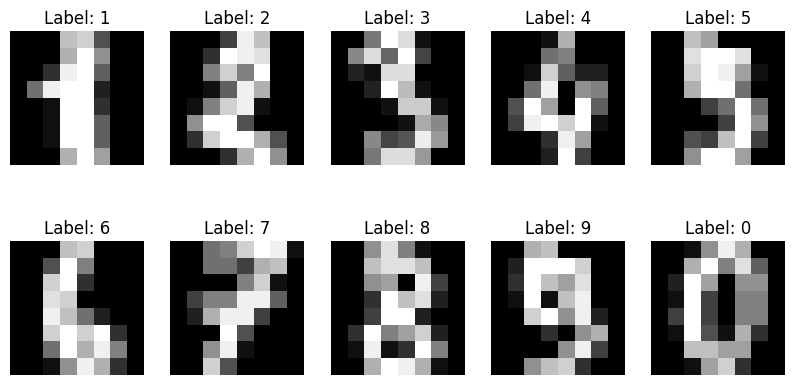

In [276]:
# Display the first few images and their corresponding labels
plt.figure(figsize=(10, 5))

for i in range(1, 11):
    plt.subplot(2, 5, i)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f'Label: {digits.target[i]}')
    plt.axis('off')

plt.show()


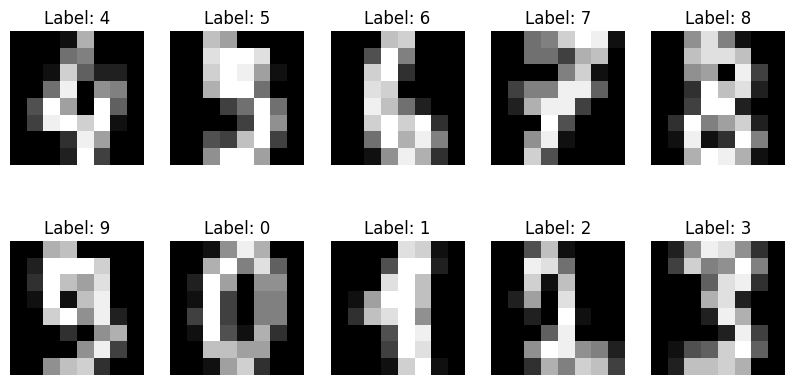

In [277]:
# Display the first few images and their corresponding labels
plt.figure(figsize=(10, 5))

for i in range(1, 11):
    plt.subplot(2, 5, i)
    plt.imshow(digits.images[i+3], cmap='gray')
    plt.title(f'Label: {digits.target[i+3]}')
    plt.axis('off')

plt.show()


In [278]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(digits.data,
                                                    digits.target,
                                                    test_size=0.2,
                                                    random_state=42)



In [279]:
# Feature scaling (optional but recommended for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [280]:
# Initialize the KNN classifier
knn = KNeighborsClassifier(
    n_neighbors=5)  # n_neighbors is the number of neighbors to use

# Train the classifier
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Step 6: Make Predictions on the Test Set


In [281]:
# Make predictions on the test set
y_pred = knn.predict(X_test)

# Print the first few predictions and their corresponding true labels
print("Predicted labels: ", y_pred[:10])
print("True labels:      ", y_test[:10])

Predicted labels:  [6 9 3 7 2 1 5 2 5 2]
True labels:       [6 9 3 7 2 1 5 2 5 2]


## Step 7: Evaluate the Model


In [282]:

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


class_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", class_report)


accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

accuracy = accuracy_score(y_train, knn.predict(X_train))
print(f"Train Accuracy: {accuracy * 100:.2f}%")


Confusion Matrix:
 [[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  1 33  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  1  0 32  0  1]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  1  1  1  0  0  1 36]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      1.00      0.98        30
           9       0.95      0.90      0.92        40

    accuracy                 

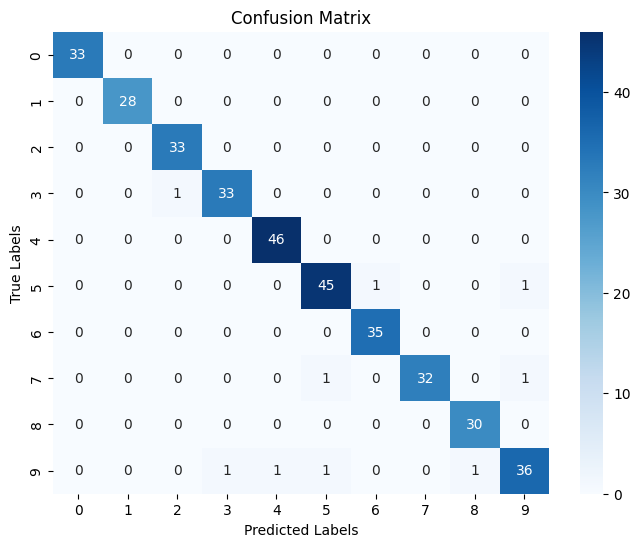

In [283]:
# Visualize the confusion matrix using a heatmap
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


## Step 9: Tune the Model (Optional)


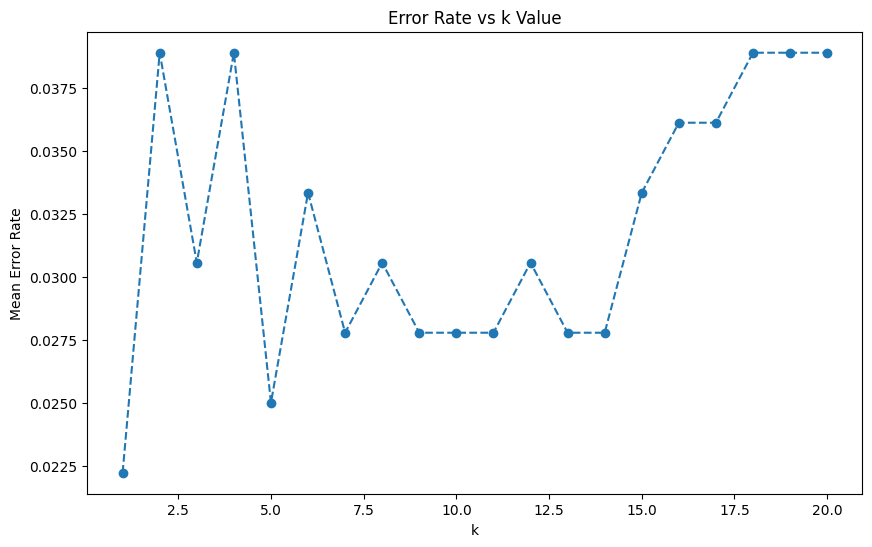

In [284]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred_k = knn.predict(X_test)
    error_rates.append(np.mean(y_pred_k != y_test))

# Plot Error Rate
plt.figure(figsize=(10,6))
plt.plot(range(1,21), error_rates, marker='o', linestyle='dashed')
plt.title('Error Rate vs k Value')
plt.xlabel('k')
plt.ylabel('Mean Error Rate')
plt.show()

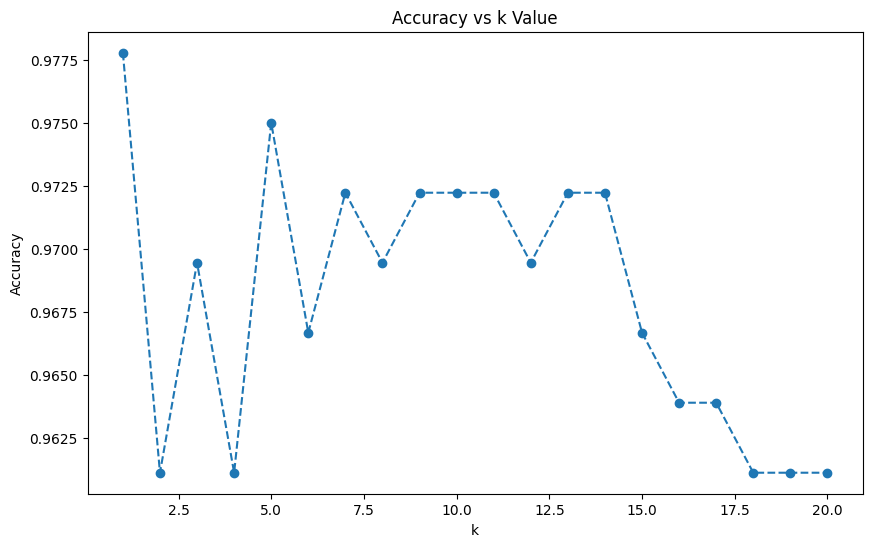

In [285]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

acc = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred_k = knn.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred_k))

# Plot Accuracy
plt.figure(figsize=(10,6))
plt.plot(range(1,21), acc, marker='o', linestyle='dashed')
plt.title('Accuracy vs k Value')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

In [286]:
min(error_rates[1:])

np.float64(0.025)

In [287]:
# Based on the error rate plot, choose the optimal k
optimal_k = error_rates.index(min(error_rates[1:])) + 1
print(f"The optimal value of k is {optimal_k}")

# Retrain the model with the optimal k
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

# Evaluate the final model
y_pred_optimal = knn_optimal.predict(X_test)
print(f"Final Accuracy with k={optimal_k}: {accuracy_score(y_test, y_pred_optimal) * 100:.2f}%")


The optimal value of k is 5
Final Accuracy with k=5: 97.50%


In [288]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


## Step 2: Load the California Housing Dataset


In [289]:
california_housing = fetch_california_housing()
data = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
data['Target'] = california_housing.target


In [290]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [291]:
X = data.drop('Target', axis=1)
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 4: Train the KNN Regressor


In [292]:
# Initialize the KNN regressor
knn_regressor = KNeighborsRegressor(n_neighbors=5)  # You can tune n_neighbors for better results

# Train the regressor
knn_regressor.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Step 5: Make Predictions on the Test Set


In [293]:

y_pred = knn_regressor.predict(X_test_scaled)



## Step 6: Evaluate the Model


In [294]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Test Mean Squared Error: {mse}")
print(f"Train Mean Squared Error: {mean_squared_error(y_train, knn_regressor.predict(X_train_scaled))}")

# Calculate R-squared (R^2) score
r2 = r2_score(y_test, y_pred)
print(f"Test R-squared: {r2}")
print(f"Train R-squared: {r2_score(y_train, knn_regressor.predict(X_train_scaled))}")

Test Mean Squared Error: 0.4324216146043236
Train Mean Squared Error: 0.2715021576485307
Test R-squared: 0.6700101862970989
Train R-squared: 0.7968981277117805


## Step 7: Tune the Model (Optional)


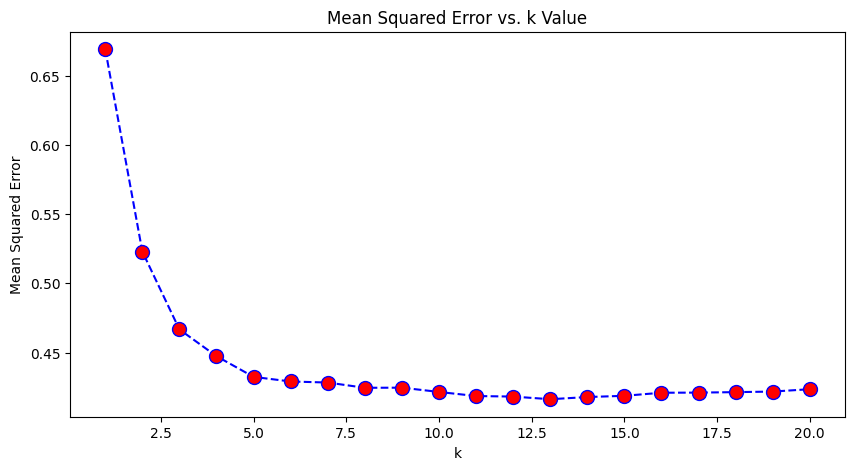

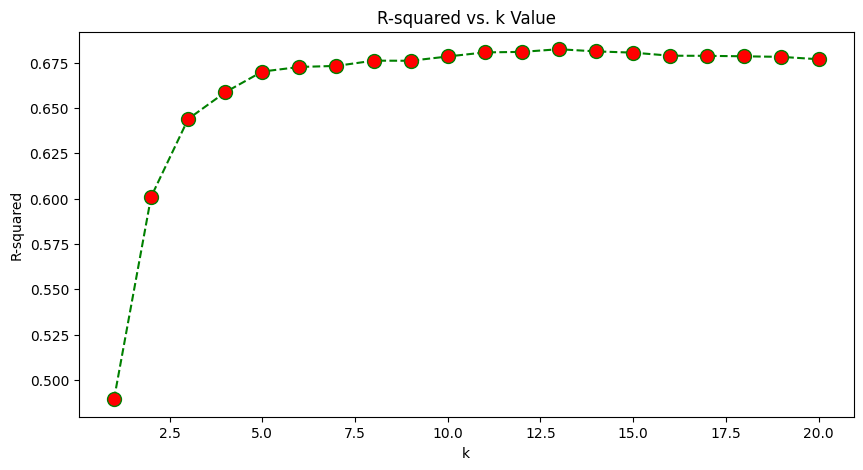

In [295]:
# Tune the KNN regressor by trying different values of k (n_neighbors)
error_rates = []
r2_scores = []

for k in range(1, 21):
    knn_regressor = KNeighborsRegressor(n_neighbors=k)
    knn_regressor.fit(X_train_scaled, y_train)
    y_pred_k = knn_regressor.predict(X_test_scaled)
    error_rates.append(mean_squared_error(y_test, y_pred_k))
    r2_scores.append(r2_score(y_test, y_pred_k))

# Plot MSE vs. k
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21),error_rates, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Mean Squared Error vs. k Value')
plt.xlabel('k')
plt.ylabel('Mean Squared Error')
plt.show()

# Plot R-squared vs. k
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), r2_scores, color='green', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('R-squared vs. k Value')
plt.xlabel('k')
plt.ylabel('R-squared')
plt.show()


In [296]:
# Based on the error rate or R-squared plot, choose the optimal k
optimal_k = error_rates.index(min(error_rates)) + 1
print(f"The optimal value of k is {optimal_k}")

# Retrain the model with the optimal k
knn_regressor_optimal = KNeighborsRegressor(n_neighbors=optimal_k)
knn_regressor_optimal.fit(X_train_scaled, y_train)

# Evaluate the final model
y_pred_optimal = knn_regressor_optimal.predict(X_test_scaled)
final_mse = mean_squared_error(y_test, y_pred_optimal)
final_r2 = r2_score(y_test, y_pred_optimal)
print(f"Final Mean Squared Error with k={optimal_k}: {final_mse}")
print(f"Final R-squared with k={optimal_k}: {final_r2}")


The optimal value of k is 13
Final Mean Squared Error with k=13: 0.41628900457117474
Final R-squared with k=13: 0.6823213122898445


In [297]:
'''param_grid = {
    'knn__n_neighbors': range(1, 21),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)'''

"param_grid = {\n    'knn__n_neighbors': range(1, 21),\n    'knn__weights': ['uniform', 'distance'],\n    'knn__metric': ['euclidean', 'manhattan']\n}\ngrid = GridSearchCV(\n    estimator=pipe,\n    param_grid=param_grid,\n    cv=5,\n    scoring='accuracy',\n    n_jobs=-1,\n    verbose=1\n)"